In [21]:
from scipy.io import loadmat
import os
import numpy as np
import pandas as pd
from scipy.signal import welch
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.metrics import precision_recall_fscore_support
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics         import classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics        import roc_curve, auc
import seaborn as sns


In [ ]:
MAIN = r"C:/NITJ/Fourth/IML-Lab/Project/SEED_Dataset(preprocessed eeg)/Preprocessed_EEG"
all_data={}
for file in os.listdir(MAIN):
    #open matlab files only
    if file.endswith(".mat"):
        FILE_PATH=os.path.join(MAIN,file)
        print(f"\nLoading: {file}")
        #load file
        data = loadmat(FILE_PATH)
        #store in dictionary
        all_data[file] = data

        #print available eeg trails
        eeg_keys=[key for key in data.keys() if "eeg" in key.lower()]
        print("EEG keys:", eeg_keys)

        for key in eeg_keys:
            print(f"{key} shape:", data[key].shape)


print("\nTotal files loaded:", len(all_data))
        
        
        


Loading: 10_20131130.mat
EEG keys: ['ww_eeg1', 'ww_eeg2', 'ww_eeg3', 'ww_eeg4', 'ww_eeg5', 'ww_eeg6', 'ww_eeg7', 'ww_eeg8', 'ww_eeg9', 'ww_eeg10', 'ww_eeg11', 'ww_eeg12', 'ww_eeg13', 'ww_eeg14', 'ww_eeg15']
ww_eeg1 shape: (62, 47001)
ww_eeg2 shape: (62, 46601)
ww_eeg3 shape: (62, 41201)
ww_eeg4 shape: (62, 47601)
ww_eeg5 shape: (62, 37001)
ww_eeg6 shape: (62, 39001)
ww_eeg7 shape: (62, 47401)
ww_eeg8 shape: (62, 43201)
ww_eeg9 shape: (62, 53001)
ww_eeg10 shape: (62, 47401)
ww_eeg11 shape: (62, 47001)
ww_eeg12 shape: (62, 46601)
ww_eeg13 shape: (62, 47001)
ww_eeg14 shape: (62, 47601)
ww_eeg15 shape: (62, 41201)

Loading: 10_20131204.mat
EEG keys: ['ww_eeg1', 'ww_eeg2', 'ww_eeg3', 'ww_eeg4', 'ww_eeg5', 'ww_eeg6', 'ww_eeg7', 'ww_eeg8', 'ww_eeg9', 'ww_eeg10', 'ww_eeg11', 'ww_eeg12', 'ww_eeg13', 'ww_eeg14', 'ww_eeg15']
ww_eeg1 shape: (62, 47001)
ww_eeg2 shape: (62, 46601)
ww_eeg3 shape: (62, 41201)
ww_eeg4 shape: (62, 47601)
ww_eeg5 shape: (62, 37001)
ww_eeg6 shape: (62, 39001)
ww_eeg7 sha

In [4]:
fs = 200  

eda_records = []

for file, mat in all_data.items():

    eeg_keys = [key for key in mat.keys() if "eeg" in key.lower()]

    for key in eeg_keys:

        trial = mat[key]  
        n_channels = trial.shape[0]
        n_samples  = trial.shape[1]
        duration_s = n_samples / fs 

        
        trial_mean   = np.mean(trial)
        trial_var    = np.var(trial)
        trial_std    = np.std(trial)
        trial_min    = np.min(trial)
        trial_max    = np.max(trial)

        eda_records.append({
            "File"        : file,
            "Trial_Key"   : key,
            "Channels"    : n_channels,
            "Samples"     : n_samples,
            "Duration(s)" : duration_s,
            "Mean"        : round(trial_mean, 4),
            "Variance"    : round(trial_var,  4),
            "Std_Dev"     : round(trial_std,  4),
            "Min"         : round(trial_min,  4),
            "Max"         : round(trial_max,  4)
        })

eda_df = pd.DataFrame(eda_records)
eda_df.head()


,File,Trial_Key,Channels,Samples,Duration(s),Mean,Variance,Std_Dev,Min,Max
0,10_20131130.mat,ww_eeg1,62,47001,235.005,-0.0777,601.8831,24.5333,-508.7554,369.7574
1,10_20131130.mat,ww_eeg2,62,46601,233.005,-0.0718,516.3993,22.7244,-210.7620,299.3941
2,10_20131130.mat,ww_eeg3,62,41201,206.005,0.2601,2870.6797,53.5787,-709.9211,780.3142
3,10_20131130.mat,ww_eeg4,62,47601,238.005,0.0385,505.4102,22.4813,-150.8296,183.1651
4,10_20131130.mat,ww_eeg5,62,37001,185.005,-0.1044,497.7393,22.3101,-300.4372,222.8916


In [5]:
eda_df.describe()

,Channels,Samples,Duration(s),Mean,Variance,Std_Dev,Min,Max
count,675.0,675.000000,675.000000,675.000000,6.750000e+02,675.000000,675.000000,675.000000
mean,62.0,45254.333333,226.271667,-0.017306,3.265644e+04,67.865412,-1571.198212,1998.747780
std,0.0,3980.531256,19.902656,0.241935,1.543768e+05,167.607695,4564.708590,9101.263755
min,62.0,37001.000000,185.005000,-3.054900,1.023737e+02,10.118000,-70501.953400,106.096300
25%,62.0,41201.000000,206.005000,-0.077600,3.335341e+02,18.262950,-1003.474000,296.562950
50%,62.0,47001.000000,235.005000,0.003300,6.332355e+02,25.164200,-594.109300,546.187200
75%,62.0,47401.000000,237.005000,0.076900,1.483131e+03,38.511400,-299.736850,1048.505350
max,62.0,53001.000000,265.005000,0.703100,1.852504e+06,1361.067400,-90.599100,215353.131300


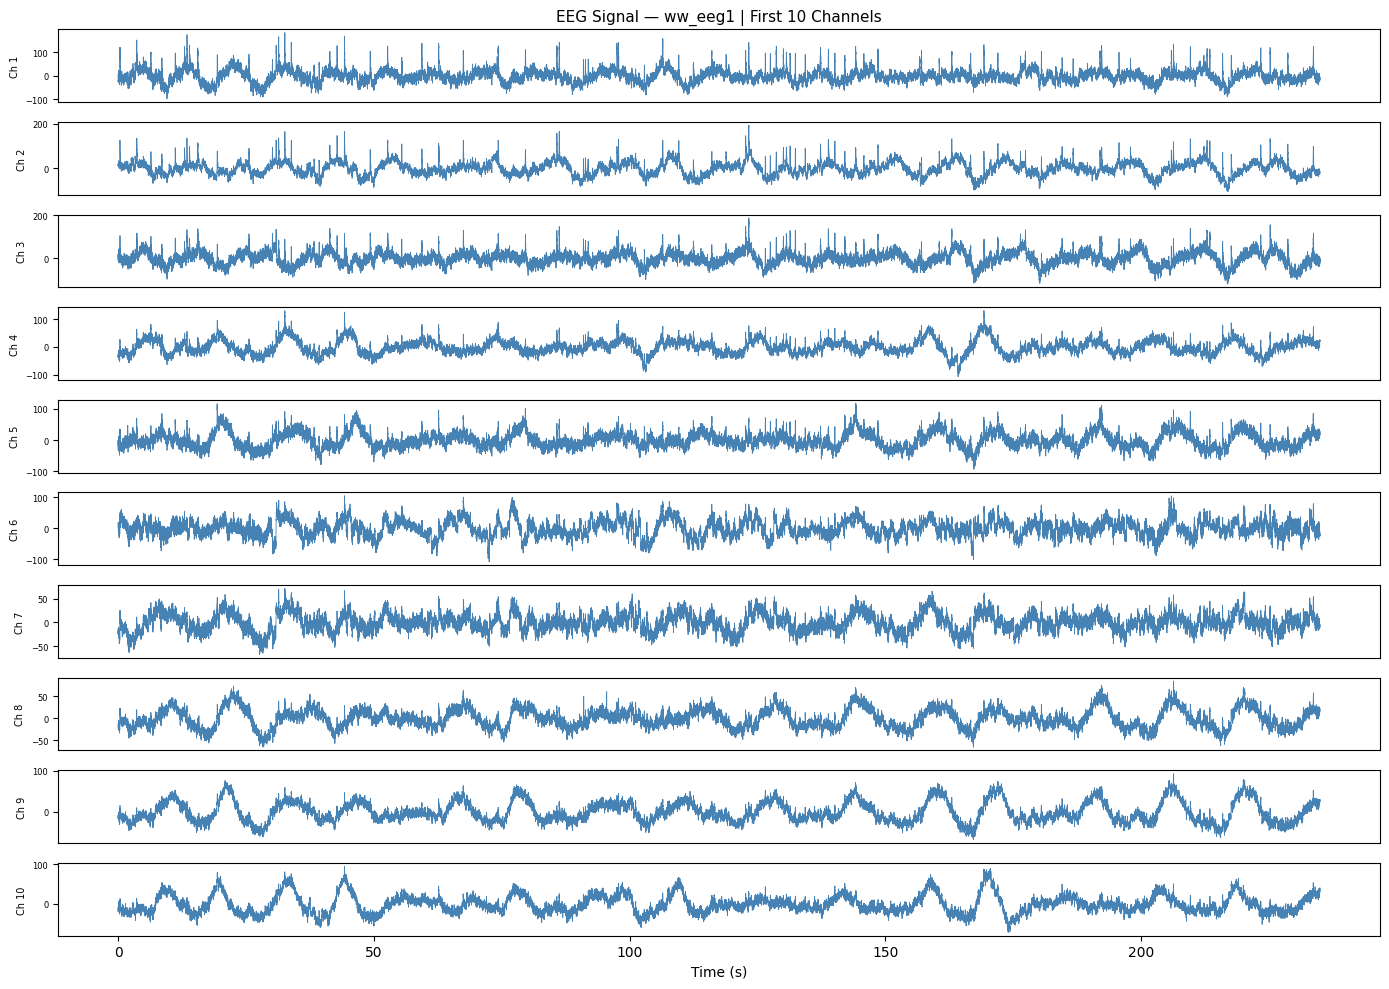

In [6]:

file = list(all_data.keys())[0]
mat        = all_data[file]
eeg_keys   = [key for key in mat.keys() if "eeg" in key.lower()]
first_key  = eeg_keys[0]

eeg   = mat[first_key]                          # Shape: (62, samples)
time  = np.arange(eeg.shape[1]) / fs           # Time axis in seconds

plt.figure(figsize=(14, 10))

for i in range(10):
    plt.subplot(10, 1, i + 1)
    plt.plot(time, eeg[i], linewidth=0.6, color='steelblue')
    plt.ylabel(f'Ch {i+1}', fontsize=7)
    plt.yticks(fontsize=6)
    if i == 0:
        plt.title(f"EEG Signal — {first_key} | First 10 Channels", fontsize=11)
    if i < 9:
        plt.xticks([])                          # Hide x-axis for all but last

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

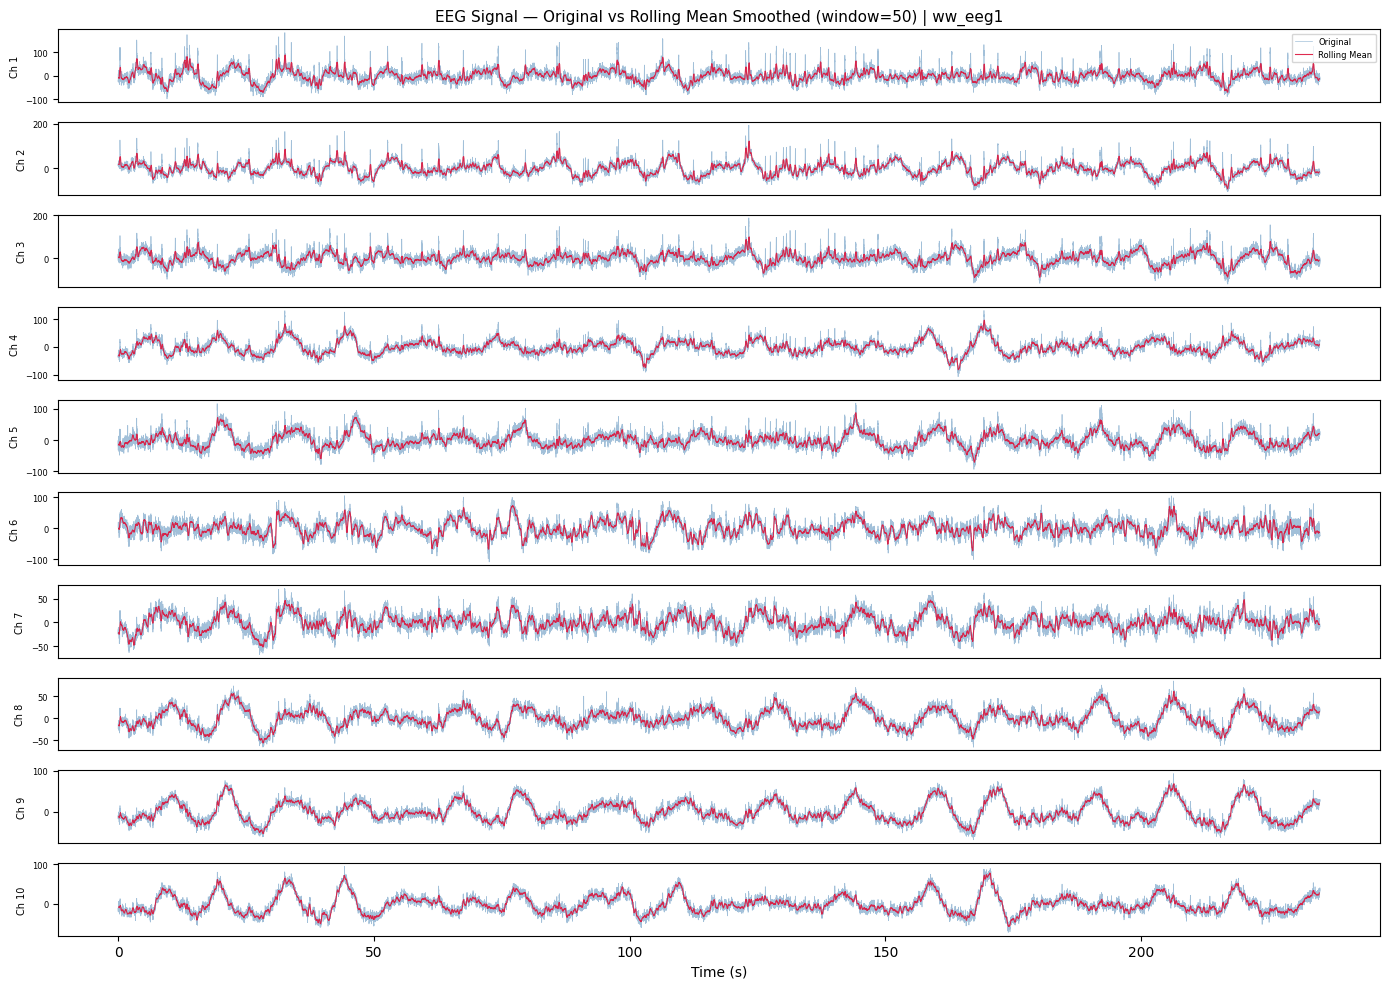

In [7]:

window = 50
plt.figure(figsize=(14, 10))

for i in range(10):

    # Convert channel signal to pandas Series
    signal_series = pd.Series(eeg[i])

    # mean averageing
    smoothed = signal_series.rolling(
        window=window,
        center=True
    ).mean()

    plt.subplot(10, 1, i + 1)

    
    plt.plot(
        time,
        eeg[i],
        linewidth=0.5,
        color='steelblue',
        alpha=0.5,
        label='Original'
    )

    # Smoothed EEG
    plt.plot(
        time,
        smoothed,
        linewidth=0.8,
        color='crimson',
        alpha=0.9,
        label='Rolling Mean'
    )

    plt.ylabel(f'Ch {i+1}', fontsize=7)
    plt.yticks(fontsize=6)

    if i == 0:
        plt.title(
            f"EEG Signal — Original vs Rolling Mean Smoothed (window={window}) | {first_key}",
            fontsize=11
        )

        plt.legend(loc='upper right', fontsize=6)

    if i < 9:
        plt.xticks([])

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

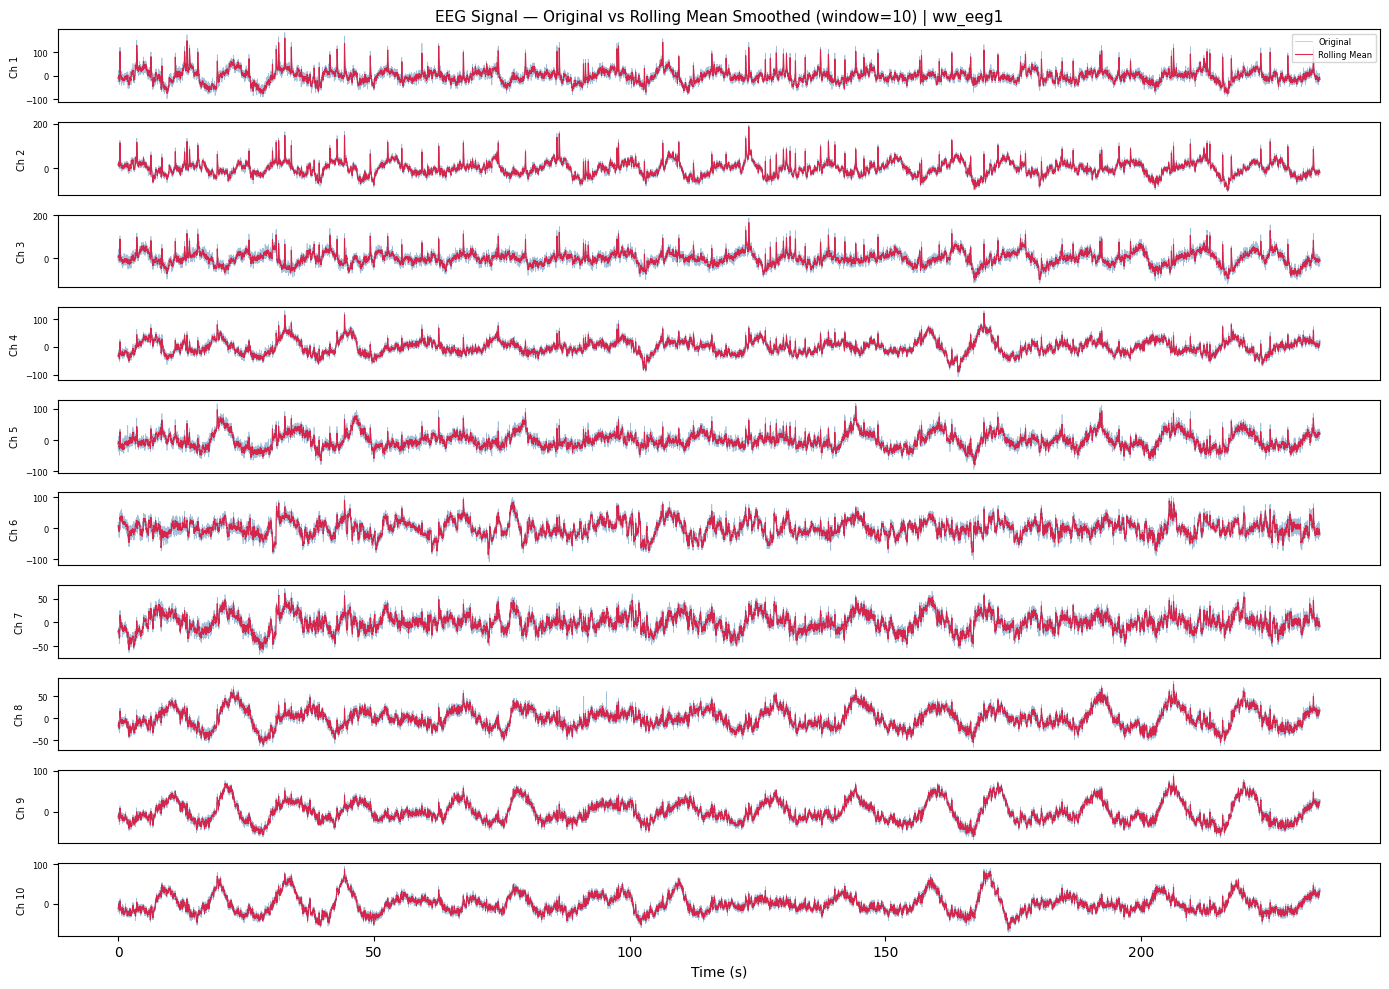

In [8]:

window = 10
plt.figure(figsize=(14, 10))

for i in range(10):

    # Convert channel signal to pandas Series
    signal_series = pd.Series(eeg[i])

    # mean averageing
    smoothed = signal_series.rolling(
        window=window,
        center=True
    ).mean()

    plt.subplot(10, 1, i + 1)

    
    plt.plot(
        time,
        eeg[i],
        linewidth=0.5,
        color='steelblue',
        alpha=0.5,
        label='Original'
    )

    # Smoothed EEG
    plt.plot(
        time,
        smoothed,
        linewidth=0.8,
        color='crimson',
        alpha=0.9,
        label='Rolling Mean'
    )

    plt.ylabel(f'Ch {i+1}', fontsize=7)
    plt.yticks(fontsize=6)

    if i == 0:
        plt.title(
            f"EEG Signal — Original vs Rolling Mean Smoothed (window={window}) | {first_key}",
            fontsize=11
        )

        plt.legend(loc='upper right', fontsize=6)

    if i < 9:
        plt.xticks([])

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

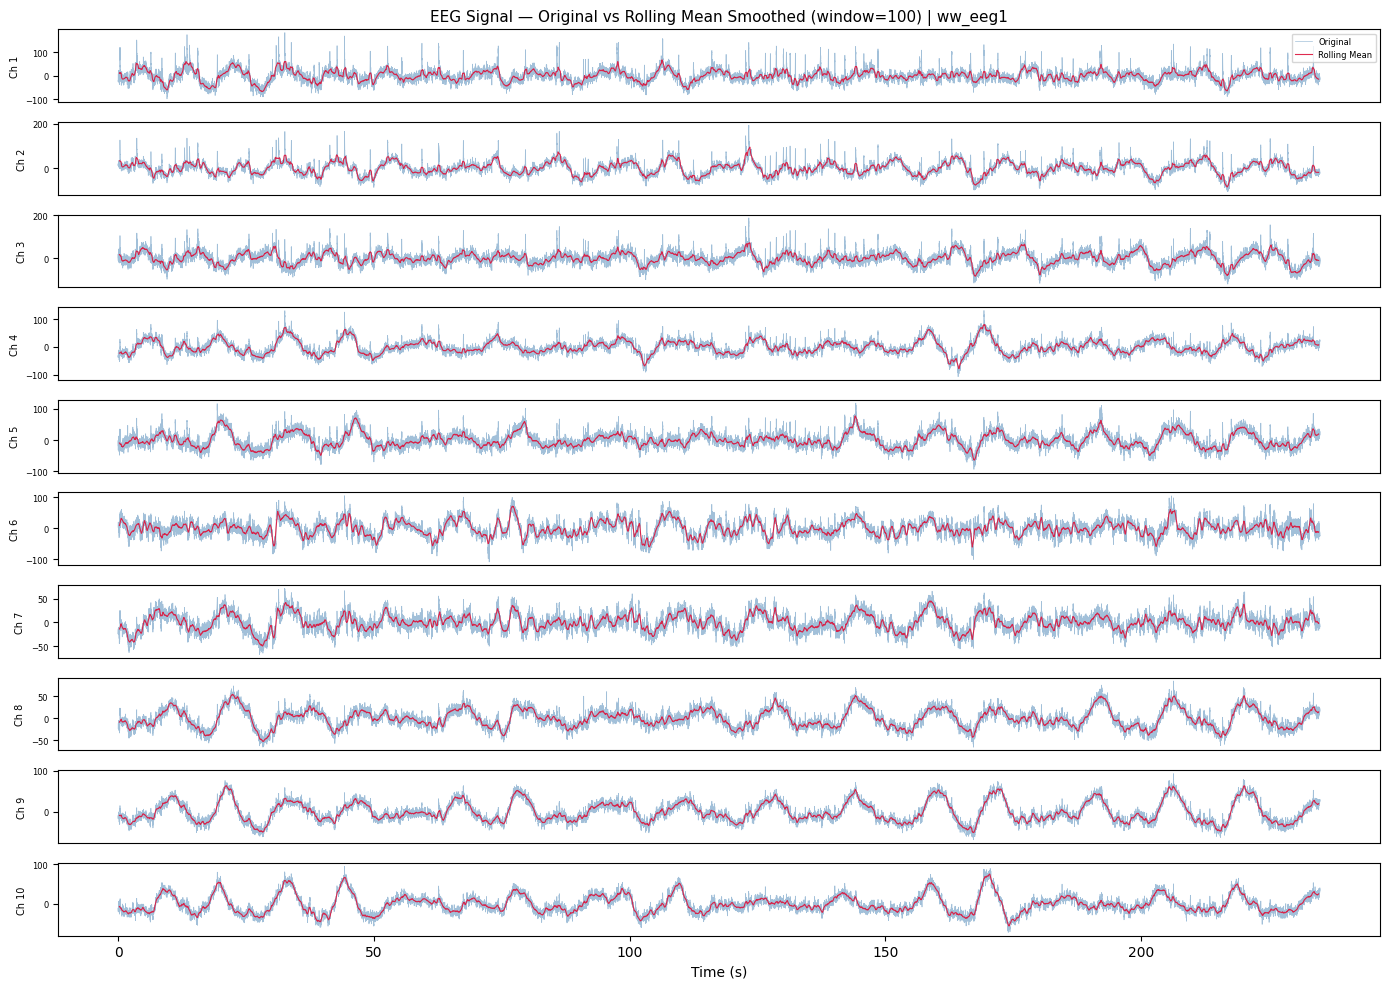

In [9]:

window = 100
plt.figure(figsize=(14, 10))

for i in range(10):

    # Convert channel signal to pandas Series
    signal_series = pd.Series(eeg[i])

    # mean averageing
    smoothed = signal_series.rolling(
        window=window,
        center=True
    ).mean()

    plt.subplot(10, 1, i + 1)

    
    plt.plot(
        time,
        eeg[i],
        linewidth=0.5,
        color='steelblue',
        alpha=0.5,
        label='Original'
    )

    # Smoothed EEG
    plt.plot(
        time,
        smoothed,
        linewidth=0.8,
        color='crimson',
        alpha=0.9,
        label='Rolling Mean'
    )

    plt.ylabel(f'Ch {i+1}', fontsize=7)
    plt.yticks(fontsize=6)

    if i == 0:
        plt.title(
            f"EEG Signal — Original vs Rolling Mean Smoothed (window={window}) | {first_key}",
            fontsize=11
        )

        plt.legend(loc='upper right', fontsize=6)

    if i < 9:
        plt.xticks([])

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

In [10]:
bands = {
    "Theta" : (4,  8),
    "Alpha" : (8,  13),
    "Beta"  : (13, 30),
    "Gamma" : (30, 50)
}

def get_band_power(psd, freqs, low, high):
    #average power bet the bands
    idx = np.where((freqs >= low) & (freqs <= high))[0]
    return np.mean(psd[idx])

band_records = []
for ch in range(eeg.shape[0]):
    freqs, psd = welch(eeg[ch], fs=fs, nperseg=256)

    row = {"Channel": ch + 1}
    total_power = np.sum(psd)

    for band_name, (low, high) in bands.items():
        bp = get_band_power(psd, freqs, low, high)
        row[f"{band_name}_Power"]    = round(bp, 4)
        row[f"{band_name}_Relative"] = round(bp / total_power, 4)

    band_records.append(row)

band_df = pd.DataFrame(band_records)
band_df.head()

,Channel,Theta_Power,Theta_Relative,Alpha_Power,Alpha_Relative,Beta_Power,Beta_Relative,Gamma_Power,Gamma_Relative
0,1,12.5657,0.0256,3.2726,0.0067,1.0306,0.0021,0.6625,0.0013
1,2,11.4025,0.0265,3.0078,0.0070,0.6459,0.0015,0.3073,0.0007
2,3,10.5069,0.0220,3.0922,0.0065,1.5072,0.0032,1.0825,0.0023
3,4,4.8026,0.0264,1.7690,0.0097,0.5900,0.0032,0.2901,0.0016
4,5,5.0748,0.0232,1.9968,0.0091,0.9717,0.0044,0.5695,0.0026


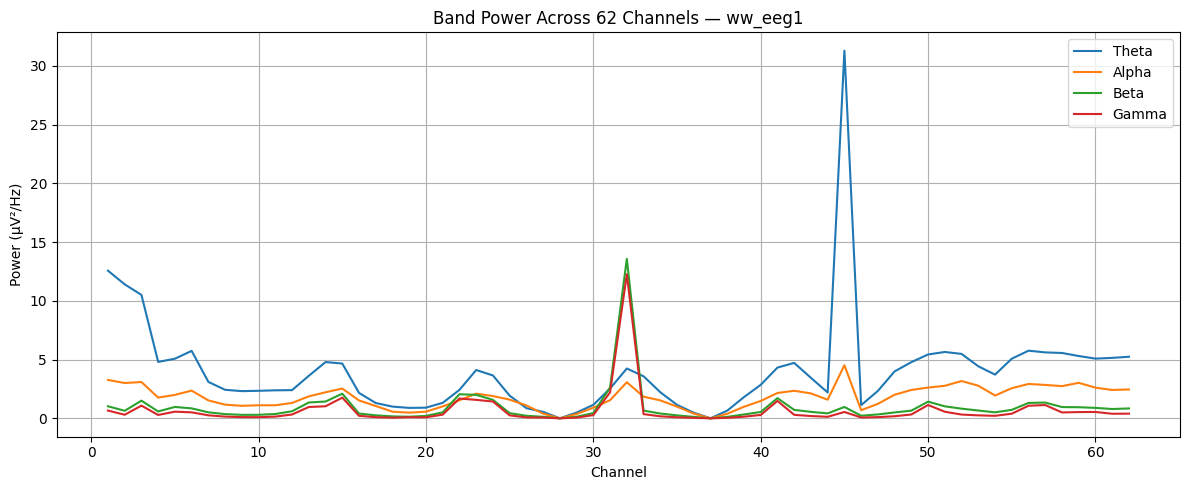

In [11]:
plt.figure(figsize=(12, 5))

for band_name in bands.keys():
    plt.plot(band_df["Channel"], band_df[f"{band_name}_Power"], label=band_name, linewidth=1.5)

plt.title(f"Band Power Across 62 Channels — {first_key}")
plt.xlabel("Channel")
plt.ylabel("Power (µV²/Hz)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
bands = {
    "Theta" : (4,  8),
    "Alpha" : (8,  13),
    "Beta"  : (13, 30),
    "Gamma" : (30, 50)
}

def get_band_power(psd, freqs, low, high):
    idx = np.where((freqs >= low) & (freqs <= high))[0]
    return np.mean(psd[idx])

band_records = []
for ch in range(eeg.shape[0]):
    freqs, psd = welch(eeg[ch], fs=fs, nperseg=256)

    row = {"Channel": ch + 1}
    total_power = np.sum(psd)

    for band_name, (low, high) in bands.items():
        bp = get_band_power(psd, freqs, low, high)
        row[f"{band_name}_Power"]    = round(bp, 4)
        row[f"{band_name}_Relative"] = round(bp / total_power, 4)

    band_records.append(row)

band_df = pd.DataFrame(band_records)
band_df.head()

,Channel,Theta_Power,Theta_Relative,Alpha_Power,Alpha_Relative,Beta_Power,Beta_Relative,Gamma_Power,Gamma_Relative
0,1,12.5657,0.0256,3.2726,0.0067,1.0306,0.0021,0.6625,0.0013
1,2,11.4025,0.0265,3.0078,0.0070,0.6459,0.0015,0.3073,0.0007
2,3,10.5069,0.0220,3.0922,0.0065,1.5072,0.0032,1.0825,0.0023
3,4,4.8026,0.0264,1.7690,0.0097,0.5900,0.0032,0.2901,0.0016
4,5,5.0748,0.0232,1.9968,0.0091,0.9717,0.0044,0.5695,0.0026


In [22]:
label_path = r"C:/NITJ/Fourth/IML-Lab/Project/SEED_Dataset(preprocessed eeg)/Preprocessed_EEG/label.mat"
label_mat  = loadmat(label_path)
labels_raw = label_mat['label'].flatten()

print("Labels:", labels_raw)        # should print [-1 -1 0 0 1 1 ...] style array
print("Total trials:", len(labels_raw))  # should be 15

def butter_bandpass(low, high, fs, order=4):
    nyq  = fs / 2
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return b, a

def compute_de(signal):
    variance = np.var(signal)
    return 0.5 * np.log(2 * np.pi * np.e * variance)

window_size = 800   # 4 seconds at 200 Hz
de_all      = []
labels_all  = []

for trial_idx, key in enumerate(eeg_keys):
    trial     = mat[key]                # (62, samples)
    n_windows = trial.shape[1] // window_size
    label     = labels_raw[trial_idx]  # -1, 0, or 1

    for w in range(n_windows):
        start = w * window_size
        end   = start + window_size
        row   = []

        for band_name, (low, high) in bands.items():
            b, a = butter_bandpass(low, high, fs)
            for ch in range(trial.shape[0]):
                segment  = trial[ch, start:end]
                filtered = filtfilt(b, a, segment)
                row.append(compute_de(filtered))   # 4 bands × 62 ch = 248 features

        de_all.append(row)
        labels_all.append(label)

X = np.array(de_all)
y = np.array(labels_all)

print("Feature matrix:", X.shape)   # (total_windows, 248)
print("Labels shape  :", y.shape)
print("Unique labels :", np.unique(y))

Labels: [ 1  0 -1 -1  0  1 -1  0  1  1  0 -1  0  1 -1]
Total trials: 15
Feature matrix: (842, 248)
Labels shape  : (842,)
Unique labels : [-1  0  1]


In [23]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred,
      target_names=["Negative", "Neutral", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.95      0.93      0.94        59
     Neutral       0.85      0.90      0.87        50
    Positive       0.95      0.92      0.93        60

    accuracy                           0.92       169
   macro avg       0.92      0.92      0.92       169
weighted avg       0.92      0.92      0.92       169



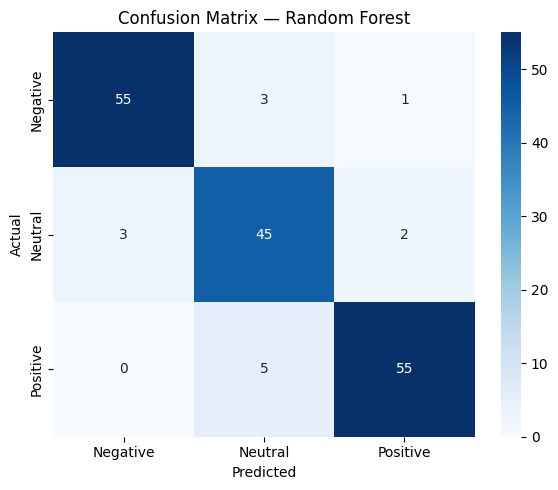

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative","Neutral","Positive"],
            yticklabels=["Negative","Neutral","Positive"])
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

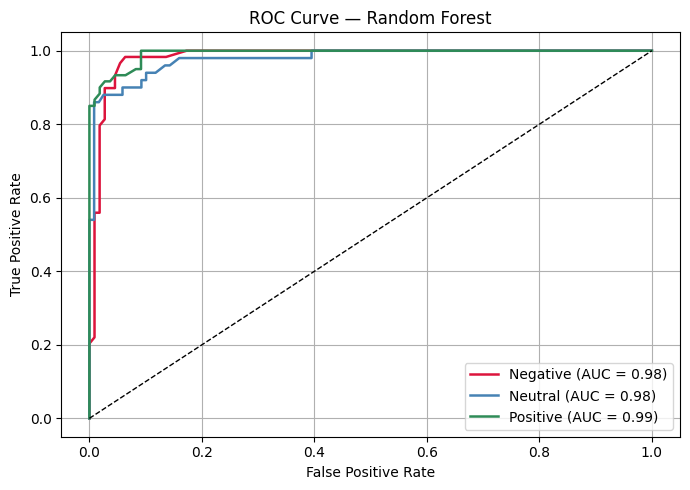

In [27]:


y_test_bin = label_binarize(y_test, classes=[-1, 0, 1])
y_prob     = rf.predict_proba(X_test)             # (n_samples, 3)

colors  = ['crimson', 'steelblue', 'seagreen']
classes = ["Negative", "Neutral", "Positive"]

plt.figure(figsize=(7, 5))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], linewidth=1.8,
             label=f"{classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--', linewidth=1)
plt.title("ROC Curve — Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

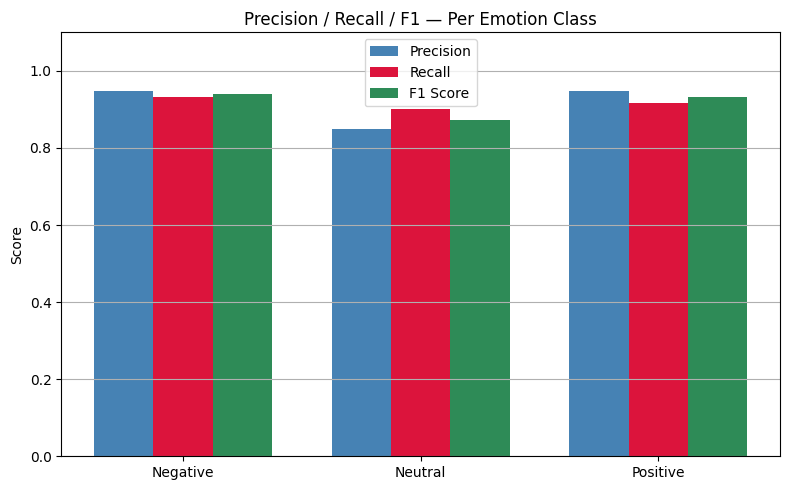

In [26]:

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=[-1, 0, 1]
)

classes  = ["Negative", "Neutral", "Positive"]
x        = np.arange(len(classes))
width    = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, precision, width, label='Precision', color='steelblue')
plt.bar(x,         recall,    width, label='Recall',    color='crimson')
plt.bar(x + width, f1,        width, label='F1 Score',  color='seagreen')

plt.xticks(x, classes)
plt.ylim(0, 1.1)
plt.title("Precision / Recall / F1 — Per Emotion Class")
plt.ylabel("Score")
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

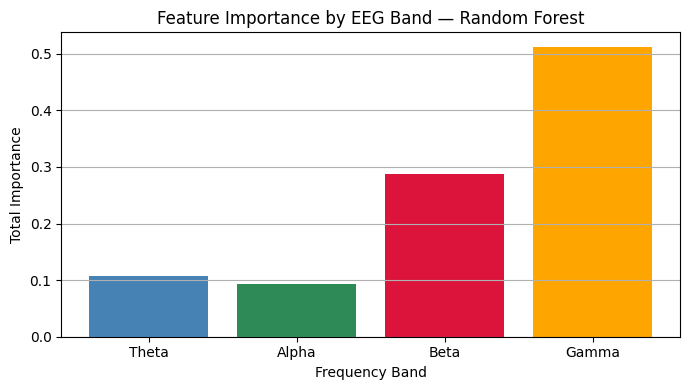

In [28]:
# 248 features = 4 bands × 62 channels
# Aggregate importance per band for clean visualization

importances  = rf.feature_importances_         # (248,)
band_names   = list(bands.keys())              # Theta, Alpha, Beta, Gamma
n_channels   = 62
band_importance = {}

for i, band_name in enumerate(band_names):
    start = i * n_channels
    end   = start + n_channels
    band_importance[band_name] = np.sum(importances[start:end])

plt.figure(figsize=(7, 4))
plt.bar(band_importance.keys(), band_importance.values(),
        color=['steelblue','seagreen','crimson','orange'])
plt.title("Feature Importance by EEG Band — Random Forest")
plt.xlabel("Frequency Band")
plt.ylabel("Total Importance")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

C:\Users\narin\AppData\Local\Temp\ipykernel_26820\41504896.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=de_plot_df, x="Emotion", y=f"{band_name}_mean",
C:\Users\narin\AppData\Local\Temp\ipykernel_26820\41504896.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=de_plot_df, x="Emotion", y=f"{band_name}_mean",
C:\Users\narin\AppData\Local\Temp\ipykernel_26820\41504896.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=de_plot_df, x="Emotion", y=f"{band_name}_mean",
C:\Users\narin\AppData\Local\Temp\ipykernel_26820\41

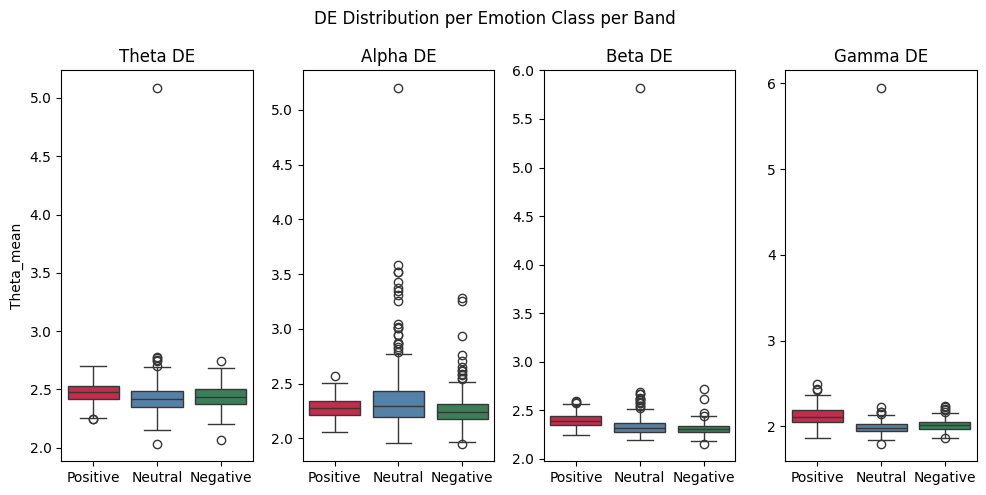

In [29]:
# Build DataFrame with DE features + labels
de_col_names = [f"{b}_Ch{ch+1}" for b in bands.keys() for ch in range(62)]
de_plot_df   = pd.DataFrame(X, columns=de_col_names)
de_plot_df["Label"] = y

emotion_map  = {-1: "Negative", 0: "Neutral", 1: "Positive"}
de_plot_df["Emotion"] = de_plot_df["Label"].map(emotion_map)

# Average DE across channels per band per window
for band_name in bands.keys():
    cols = [f"{band_name}_Ch{ch+1}" for ch in range(62)]
    de_plot_df[f"{band_name}_mean"] = de_plot_df[cols].mean(axis=1)

plt.figure(figsize=(10, 5))

for i, band_name in enumerate(bands.keys()):
    plt.subplot(1, 4, i + 1)
    sns.boxplot(data=de_plot_df, x="Emotion", y=f"{band_name}_mean",
                palette=["crimson","steelblue","seagreen"])
    plt.title(f"{band_name} DE")
    plt.xlabel("")
    if i != 0:
        plt.ylabel("")

plt.suptitle("DE Distribution per Emotion Class per Band", fontsize=12)
plt.tight_layout()
plt.show()